# Loan Default Prediction - Model Training
This notebook contains the data preprocessing, model training (with class balancing), and evaluation pipeline.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

In [35]:
# 1. Load Data
data_path = 'data/Loan_default.csv'
df = pd.read_csv(data_path)
print(f"Initial data shape: {df.shape}")
print("Class Distribution:\n", df['Default'].value_counts(normalize=True))
df.head()

Initial data shape: (255347, 18)
Class Distribution:
 Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [36]:
# 2. Preprocessing - Outlier Removal using IQR
cols_to_check = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Data shape after outlier removal: {df.shape}")

Data shape after outlier removal: (255347, 18)


In [37]:
# 3. Preprocessing - Feature Encoding
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

y = df['Default']
X = df.drop(columns=['Default', 'LoanID'])

cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)
print(f"Encoded features shape: {X_encoded.shape}")

Encoded features shape: (255347, 28)


In [38]:
# 4. Data Splitting and Scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("Data Split and Scaling Complete.")

Data Split and Scaling Complete.


In [39]:
# 5. Final Model (Random Forest with Balanced Weights)
# Using RandomForest with class_weight='balanced' to handle imbalance
final_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42)
final_model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, final_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, final_model.predict(X_test_scaled))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

Training Accuracy: 0.7451
Testing Accuracy:  0.7282



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83     45170
           1       0.24      0.63      0.35      5900

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.77     51070



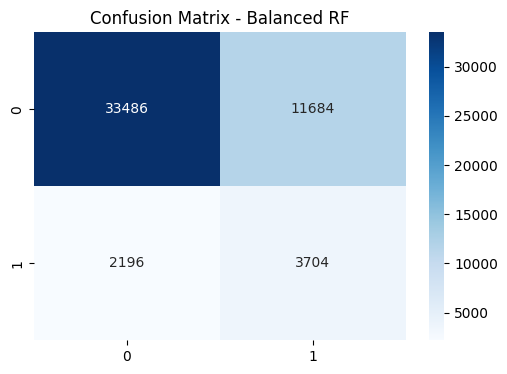

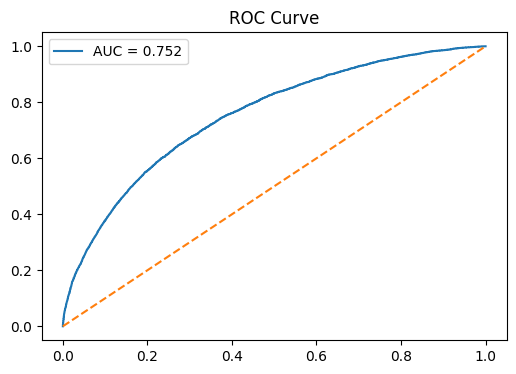

In [40]:
# 6. Evaluation & Visualization
y_preds = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]
print("\nClassification Report:")
print(classification_report(y_test, y_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Balanced RF")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.legend()
plt.show()

In [41]:
# 7. Model Export
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(ct, "models/encoder.pkl")
joblib.dump(X.columns.tolist(), "models/feature_names.pkl") # Save column names for alignment
print("Model components and feature names saved to models/")

Model components and feature names saved to models/
